# iFood Case — Notebook 2: Causal Modeling & Offer Policy

**The case question:** *which offer should be sent to each customer?*

**Approach overview:**

```
dataset_unified.parquet (from Notebook 1)
        │
        ▼
 1. Prep: treatment labels · imputation with flags · customer-grouped train/test split
        │
        ▼
 2. Average effects under randomization ──► naive diff-in-means + OLS with customer-clustered SEs
        │                                    (exact inference; anchors everything downstream)
        ▼
 3. CausalForestDML (multi-valued treatment: 8 offers vs. informational control)
        │        LightGBM nuisances · customer-grouped cross-fitting · batched CATE scoring
        ▼
 4-5. Heterogeneity + validation (decile calibration, Qini)
        │
        ▼
 6. Model comparison: S/T/X/DR-learners scored by R-loss + uplift AUUC
        │
        ▼
 7. Retention model (post-expiry repurchase)
        │
        ▼
 8-9. Offer policy: argmax net incremental value ──► plug-in and doubly-robust value estimates
        │                                            + interpretable policy tree
        ▼
10. Refutation: placebo (permuted treatment) · overlap sensitivity
```

**Identification.** Offer allocation in this test is randomized (balance checks and near-zero
covariate correlations in Notebook 1). Consequences that shape this notebook:
- The simple difference in means is an unbiased ATE estimator, and OLS with customer-clustered
  standard errors gives **exact randomization-based inference** — this is our inference workhorse.
- DML/CausalForest is used for what it is good at here: **regularized heterogeneity (CATE)**
  estimation and variance reduction — *not* confounding correction. Its treatment model converges
  to the (known, constant) propensities and acts as insurance against accidental finite-sample
  imbalance.
- No inverse-propensity weighting is applied for identification: with known uniform propensities,
  estimated-IPW adds variance and removes no bias. The one place propensities are legitimately
  used is the **doubly-robust off-policy evaluation** of the final policy (Section 8), where they
  are known by design.


## 0. Setup

In [0]:
%pip install econml==0.15.1 lightgbm --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from econml.dml import CausalForestDML

SEED = 42
VOLUME = "/Volumes/workspace/default/ifood_case"
np.random.seed(SEED)

df = spark.read.parquet(f"{VOLUME}/processed/dataset_unified.parquet").toPandas()
print(df.shape)

(76277, 39)


## 1. Preparation

- **Treatment labels:** one label per offer (type + discount/min + duration); `control` = the two
  `informational` offers pooled (both have zero discount; they differ only in duration/channel).
- **X (heterogeneity features):** demographics + RFM + offer history — all strictly pre-`t0`.
- **W (nuisance-only controls):** X + send wave (`t0`) + `n_overlapping_offers` (controls the
  window-contamination identified in Notebook 1 — ~82% of instances have some overlap).
- **Channels are excluded from X/W:** channel mix is an attribute of the offer (part of the
  treatment package), not of the customer; conditioning on it would absorb treatment variation.
- **Missing values:** LightGBM handles NaN in the nuisances, but the final causal forest does not,
  so we impute explicitly and keep missingness flags (the pattern is informative).

In [0]:
# --- Treatment labels ------------------------------------------------------
df["t_label"] = np.where(
    df["offer_type"] == "informational", "control",
    df["offer_type"].str[:4] + "_" + df["discount_value"].astype(int).astype(str)
    + "of" + df["min_value"].astype(int).astype(str)
    + "_" + df["duration"].astype(int).astype(str) + "d")

labels = ["control"] + sorted(df.loc[df["t_label"] != "control", "t_label"].unique())
code_map = {l: i for i, l in enumerate(labels)}
df["T"] = df["t_label"].map(code_map)
print(df.groupby("t_label")["T"].agg(["first", "count"]))

# --- Imputation with flags ---------------------------------------------------
df["never_purchased"] = (df["freq_pre"] == 0).astype(int)
df["recency_pre"]     = df["recency_pre"].fillna(df["t0"])   # no prior purchase: recency = whole observed life
df["avg_ticket_pre"]  = df["avg_ticket_pre"].fillna(0.0)
for c in ["age", "credit_card_limit"]:
    df[c] = df[c].fillna(df[c].median())                      # flag already exists: incomplete_profile

df = pd.get_dummies(df, columns=["gender"], prefix="gen", dtype=int)

X_COLS = ["age", "credit_card_limit", "tenure_days", "incomplete_profile",
          "freq_pre", "spend_pre", "avg_ticket_pre", "recency_pre", "never_purchased",
          "received_pre", "viewed_pre", "completed_pre",
          "gen_F", "gen_M", "gen_O"]
X_COLS = [c for c in X_COLS if c in df.columns]
W_EXTRA = ["t0", "n_overlapping_offers"]

assert df[X_COLS + W_EXTRA].isna().sum().sum() == 0

                first  count
t_label                     
bogo_10of10_5d      1   7593
bogo_10of10_7d      2   7658
bogo_5of5_5d        3   7571
bogo_5of5_7d        4   7677
control             0  15235
disc_2of10_10d      5   7597
disc_2of10_7d       6   7632
disc_3of7_7d        7   7646
disc_5of20_10d      8   7668


### 1.1 Customer-grouped train/test split

The same customer never appears on both sides (prevents leakage across instances of the same customer).

In [0]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
idx_tr, idx_te = next(gss.split(df, groups=df["account_id"]))
tr, te = df.iloc[idx_tr].copy(), df.iloc[idx_te].copy()
print(f"train: {len(tr):,} instances / {tr.account_id.nunique():,} customers")
print(f"test : {len(te):,} instances / {te.account_id.nunique():,} customers")
assert set(tr.account_id) & set(te.account_id) == set()

train: 53,445 instances / 11,895 customers
test : 22,832 instances / 5,099 customers


## 2. Average effects under randomization

Two estimators, one purpose:
- **Naive difference in means** — unbiased under randomization; the sanity anchor.
- **Saturated OLS with customer-clustered standard errors** — the same point estimates with correct
  inference (each customer contributes several instances). This is the notebook's *primary*
  inference for average effects; the forest's own intervals (bootstrap-of-little-bags) do not
  cluster by customer and are not reported for ATEs.

In [0]:
def diff_in_means(data, y="y1_conv_7d"):
    """Per-arm difference in means vs. pooled control, with unclustered SEs (reference only)."""
    ctrl = data.loc[data["T"] == 0, y]
    rows = []
    for lab in labels[1:]:
        treat = data.loc[data["t_label"] == lab, y]
        diff = treat.mean() - ctrl.mean()
        se = np.sqrt(treat.var()/len(treat) + ctrl.var()/len(ctrl))
        rows.append([lab, len(treat), diff, se])
    return pd.DataFrame(rows, columns=["offer", "n", "ATE_naive", "se_naive"])

naive_y1 = diff_in_means(tr)

# --- Primary inference: saturated OLS, customer-clustered SEs (full sample: no model fitting) ---
ols = smf.ols("y1_conv_7d ~ C(t_label, Treatment('control'))", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["account_id"]})

def extract_ols(res, term_prefix="C(t_label, Treatment('control'))"):
    rows = []
    for lab in labels[1:]:
        term = f"{term_prefix}[T.{lab}]"
        ci = res.conf_int().loc[term]
        rows.append([lab, res.params[term], ci[0], ci[1]])
    return pd.DataFrame(rows, columns=["offer", "ATE_ols", "CI_low", "CI_high"])

ate_ols = extract_ols(ols)
ate_ols.merge(naive_y1[["offer", "ATE_naive"]], on="offer").round(4)

,offer,ATE_ols,CI_low,CI_high,ATE_naive
0,bogo_10of10_5d,0.0624,0.0518,0.0729,0.0652
1,bogo_10of10_7d,0.0654,0.0549,0.0760,0.0685
2,bogo_5of5_5d,0.0596,0.0490,0.0703,0.0609
3,bogo_5of5_7d,0.0036,-0.0079,0.0150,0.0040
4,disc_2of10_10d,0.0840,0.0738,0.0943,0.0822
5,disc_2of10_7d,0.0055,-0.0059,0.0170,0.0032
6,disc_3of7_7d,0.0758,0.0652,0.0863,0.0772
7,disc_5of20_10d,-0.0191,-0.0309,-0.0074,-0.0194


## 3. CausalForestDML — heterogeneous effects on 7-day conversion

- **Nuisances:** `E[Y|X,W]` with LGBMRegressor; `E[T|X,W]` (multiclass propensity) with
  LGBMClassifier — both cross-fitted with `GroupKFold(3)` by customer (`groups=`).
- **Causal forest** on the orthogonalized residuals; multi-valued discrete treatment
  (8 arms vs. control).
- **Runtime:** ~5–10 min on serverless. If memory becomes an issue, reduce `n_estimators`
  to 400 and `max_samples` to 0.3 (slightly wider heterogeneity estimates, nothing structural).

In [0]:
Y_tr = tr["y1_conv_7d"].values
T_tr = tr["T"].values
X_tr = tr[X_COLS].values.astype(float)
W_tr = tr[X_COLS + W_EXTRA].values.astype(float)
g_tr = tr["account_id"].values

cf_y1 = CausalForestDML(
    model_y=LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                          min_child_samples=100, random_state=SEED, verbose=-1),
    model_t=LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                           min_child_samples=100, random_state=SEED, verbose=-1),
    discrete_treatment=True,
    cv=GroupKFold(n_splits=3),
    n_estimators=800,
    min_samples_leaf=50,
    max_samples=0.45,
    random_state=SEED,
)
cf_y1.fit(Y_tr, T_tr, X=X_tr, W=W_tr, groups=g_tr, cache_values=True)
print("fitted")

fitted


### 3.1 Batched CATE scoring + point-estimate cross-check

Scoring the full holdout at once through the forest's inference machinery exhausts driver memory
(it materializes per-observation covariance blocks). Point estimates are cheap, so we score in
batches and persist the CATE matrix; **inference for average effects stays with the clustered OLS
of Section 2** (exact under randomization). The forest's ATE points must be statistically
compatible with OLS — systematic divergence would signal a pipeline bug, not sophistication.

In [0]:
X_te = te[X_COLS].values.astype(float)

def cme_in_batches(est, X, n_batch=4000):
    """Constant marginal effects (CATE matrix, n x n_arms) computed in batches to cap peak memory."""
    parts = []
    for i in range(0, len(X), n_batch):
        parts.append(np.asarray(est.const_marginal_effect(X[i:i + n_batch])).reshape(-1, len(labels) - 1))
        gc.collect()
    return np.vstack(parts)

cme_te = cme_in_batches(cf_y1, X_te)
cate_df = pd.DataFrame(cme_te, columns=labels[1:], index=te.index)

# Persist: sections 4-9 reuse this without refitting (kernel-crash insurance)
cate_df.to_parquet(f"{VOLUME}/processed/cate_y1_holdout.parquet")

comparison = ate_ols.copy()
comparison["ATE_dml_point"] = cate_df.mean(axis=0).values
comparison["within_OLS_CI"] = ((comparison["ATE_dml_point"] >= comparison["CI_low"]) &
                               (comparison["ATE_dml_point"] <= comparison["CI_high"]))
comparison.round(4)

,offer,ATE_ols,CI_low,CI_high,ATE_dml_point,within_OLS_CI
0,bogo_10of10_5d,0.0624,0.0518,0.0729,0.0620,True
1,bogo_10of10_7d,0.0654,0.0549,0.0760,0.0697,True
2,bogo_5of5_5d,0.0596,0.0490,0.0703,0.0646,True
3,bogo_5of5_7d,0.0036,-0.0079,0.0150,0.0057,True
4,disc_2of10_10d,0.0840,0.0738,0.0943,0.0854,True
5,disc_2of10_7d,0.0055,-0.0059,0.0170,0.0015,True
6,disc_3of7_7d,0.0758,0.0652,0.0863,0.0785,True
7,disc_5of20_10d,-0.0191,-0.0309,-0.0074,-0.0225,True


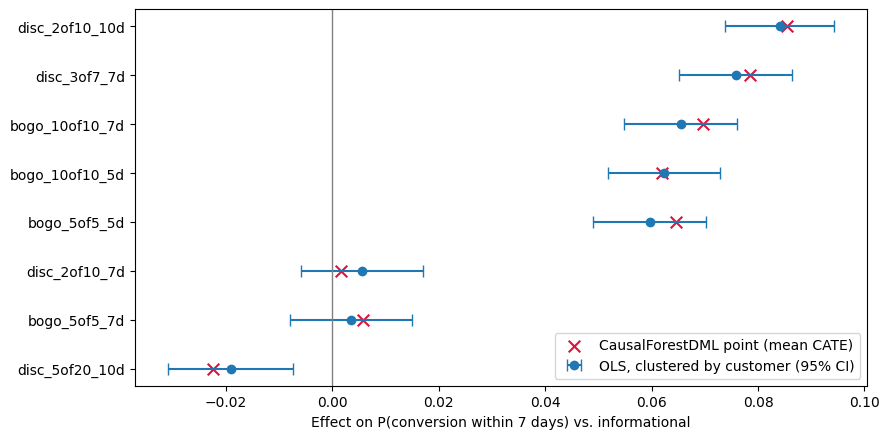

In [0]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = comparison.sort_values("ATE_ols")
ax.errorbar(order["ATE_ols"], range(len(order)),
            xerr=[order["ATE_ols"] - order["CI_low"], order["CI_high"] - order["ATE_ols"]],
            fmt="o", capsize=4, label="OLS, clustered by customer (95% CI)")
ax.scatter(order["ATE_dml_point"], range(len(order)), marker="x", s=70,
           color="crimson", label="CausalForestDML point (mean CATE)")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order["offer"])
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("Effect on P(conversion within 7 days) vs. informational")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Heterogeneity (CATE)

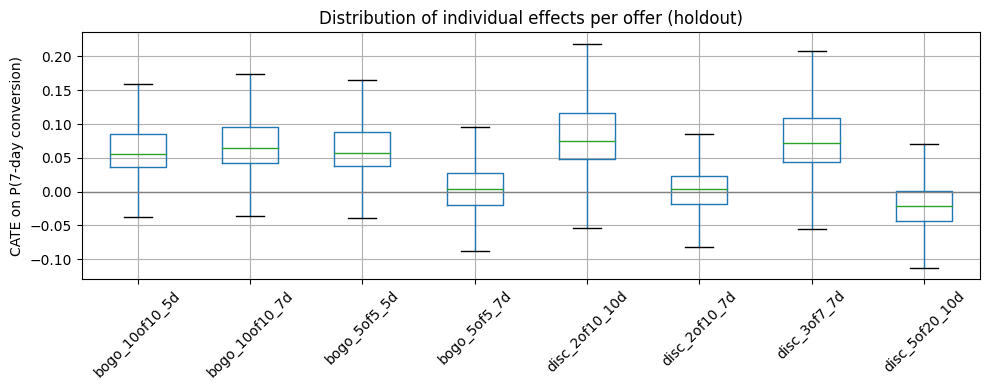

Share of customers with CATE > 0 per offer:
bogo_10of10_7d    0.958
disc_2of10_10d    0.949
disc_3of7_7d      0.941
bogo_5of5_5d      0.933
bogo_10of10_5d    0.921
disc_2of10_7d     0.554
bogo_5of5_7d      0.549
disc_5of20_10d    0.262
dtype: float64


In [0]:
fig, ax = plt.subplots(figsize=(10, 4))
cate_df.boxplot(ax=ax, rot=45, showfliers=False)
ax.axhline(0, color="gray", lw=1)
ax.set_ylabel("CATE on P(7-day conversion)")
ax.set_title("Distribution of individual effects per offer (holdout)")
plt.tight_layout(); plt.show()

print("Share of customers with CATE > 0 per offer:")
print((cate_df > 0).mean().round(3).sort_values(ascending=False))

### 4.1 What drives the heterogeneity

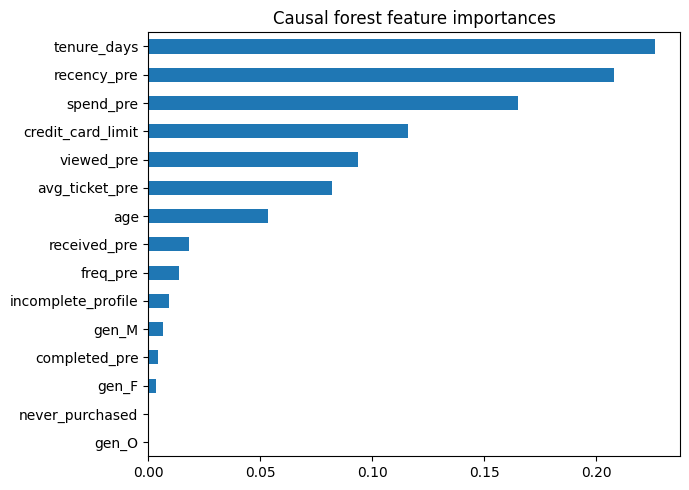

In [0]:
try:
    imp = pd.Series(cf_y1.feature_importances(), index=X_COLS)
except Exception:
    imp = pd.Series(cf_y1.feature_importances_, index=X_COLS)
imp.sort_values().plot(kind="barh", figsize=(7, 5), title="Causal forest feature importances")
plt.tight_layout(); plt.show()

In [0]:
# Profile of extreme sensitivity quartiles (for the offer with the largest ATE)
champion = comparison.sort_values("ATE_ols", ascending=False)["offer"].iloc[0]
q = pd.qcut(cate_df[champion], 4, labels=["Q1 (lowest effect)", "Q2", "Q3", "Q4 (highest effect)"])
profile = te.groupby(q)[["freq_pre", "spend_pre", "recency_pre", "never_purchased",
                         "tenure_days", "age", "credit_card_limit"]].mean()
print(f"Reference offer: {champion}")
profile.round(2)

Reference offer: disc_2of10_10d


,freq_pre,spend_pre,recency_pre,never_purchased,tenure_days,age,credit_card_limit
disc_2of10_10d,,,,,,,
Q1 (lowest effect),3.56,42.69,5.63,0.19,381.93,55.03,64652.77
Q2,5.45,51.30,3.24,0.12,553.35,53.33,59312.19
Q3,3.30,43.90,3.44,0.26,491.48,54.94,63154.70
Q4 (highest effect),1.64,42.86,2.69,0.54,649.04,54.60,73908.37


## 5. CATE validation

**Decile calibration (holdout):** rank customers by predicted CATE and compare *observed* uplift
(treated mean − control mean within each decile) against the predicted mean. Because the holdout
contains unseen customers and allocation was randomized, the observed per-decile uplift is unbiased.
Expect noise (~500 obs/decile split across arms); what matters is monotonicity and rough agreement
with the 45° line.

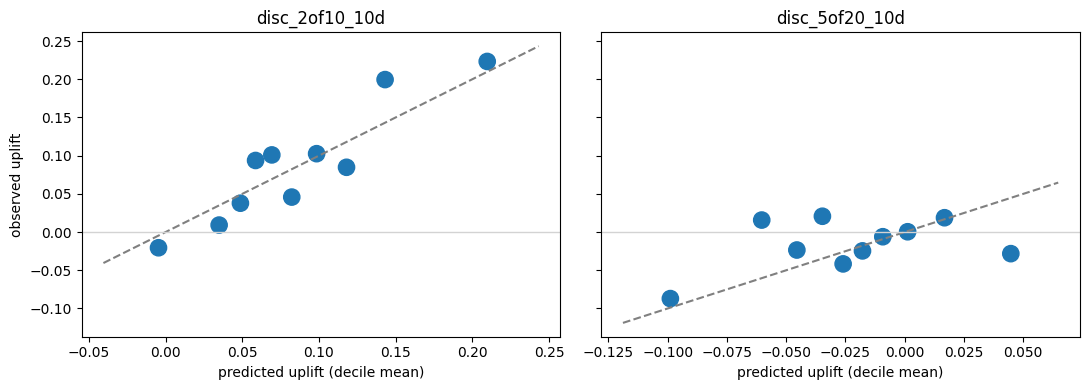

In [0]:
def decile_calibration(lab, n_dec=10):
    sub = te[te["t_label"].isin([lab, "control"])].copy()
    sub["cate_hat"] = cate_df.loc[sub.index, lab]
    sub["decile"] = pd.qcut(sub["cate_hat"], n_dec, labels=False, duplicates="drop")
    obs = sub.pivot_table(index="decile", columns="t_label", values="y1_conv_7d", aggfunc="mean")
    return pd.DataFrame({
        "predicted_uplift": sub.groupby("decile")["cate_hat"].mean(),
        "observed_uplift": obs[lab] - obs["control"],
        "n": sub.groupby("decile").size(),
    })

worst = comparison.sort_values("ATE_ols")["offer"].iloc[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, lab in zip(axes, [champion, worst]):
    cal = decile_calibration(lab)
    cols = ["predicted_uplift", "observed_uplift"]          # limits from these columns only
    ax.scatter(cal["predicted_uplift"], cal["observed_uplift"], s=cal["n"] / 5)
    lim = [cal[cols].min().min() - .02, cal[cols].max().max() + .02]
    ax.plot(lim, lim, "--", color="gray"); ax.axhline(0, color="lightgray", lw=1)
    ax.set_title(lab); ax.set_xlabel("predicted uplift (decile mean)")
axes[0].set_ylabel("observed uplift")
plt.tight_layout(); plt.show()

**Qini curve:** cumulative incremental conversions when prioritizing customers by CATE, vs. random prioritization.

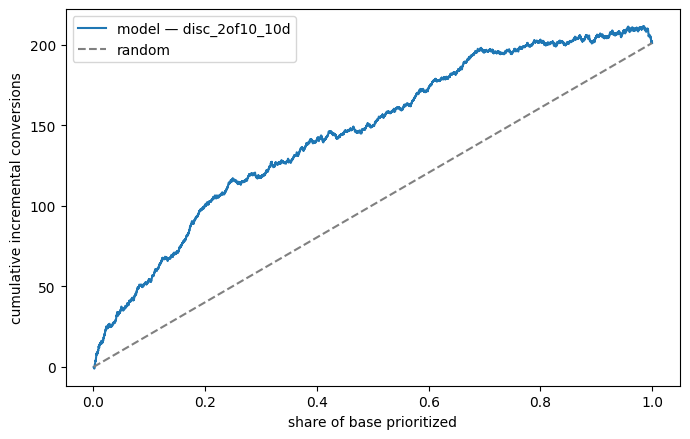

In [0]:
def qini_curve(lab, cate_vector):
    """Standard Qini: cumulative treated conversions minus scaled control conversions, ordered by score."""
    sub = te[te["t_label"].isin([lab, "control"])].copy()
    sub["score"] = cate_vector.loc[sub.index]
    sub = sub.sort_values("score", ascending=False).reset_index(drop=True)
    treated = (sub["t_label"] == lab).astype(int)
    n_t = treated.cumsum().replace(0, np.nan)
    n_c = (1 - treated).cumsum().replace(0, np.nan)
    y_t = (sub["y1_conv_7d"] * treated).cumsum()
    y_c = (sub["y1_conv_7d"] * (1 - treated)).cumsum()
    q = (y_t - y_c * (n_t / n_c)).values
    frac = np.arange(1, len(sub) + 1) / len(sub)
    return frac, q

frac, q = qini_curve(champion, cate_df[champion])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(frac, q, label=f"model — {champion}")
ax.plot(frac, frac * q[-1], "--", color="gray", label="random")
ax.set_xlabel("share of base prioritized"); ax.set_ylabel("cumulative incremental conversions")
ax.legend(); plt.tight_layout(); plt.show()

def auuc_gain(lab, cate_vector):
    """Area between the model Qini curve and the random diagonal (normalized by n).
    Leading NaNs (prefix without both arms represented) contribute ~0 and are zero-filled."""
    frac, q = qini_curve(lab, cate_vector)
    q = np.nan_to_num(q, nan=0.0)
    return float(np.trapz(q - frac * q[-1], frac))

## 6. Model comparison — is the causal forest the right learner?

Robustness through *formal model selection*, not a model zoo. Candidates cover the main
meta-learner families; all share the same LightGBM base learners for a fair comparison:

| Model | Family | Notes |
|---|---|---|
| `CausalForestDML` | R-learner / forest | current choice |
| `DRLearner` | doubly robust | natural fit for discrete multi-valued treatment |
| `XLearner` | meta-learner | strong under unbalanced arms |
| `TLearner` | meta-learner | simple baseline |
| `SLearner` | meta-learner | simple baseline; prone to regularization-induced attenuation |

Two selection criteria, both computed on held-out data:
1. **R-loss (`econml.score.RScorer`)** — the Nie–Wager loss on residualized data; the standard
   criterion for CATE model selection without ground truth (higher score = better).
2. **Uplift AUUC** on the test set for the champion arm — measures ranking quality, which is what
   the policy consumes.

Meta-learners receive `X + W` as features (they have no separate W argument).

In [0]:
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dr import DRLearner
from econml.dml import LinearDML

def lgb_r(): return LGBMRegressor(n_estimators=250, learning_rate=0.05, num_leaves=31,
                                  min_child_samples=100, random_state=SEED, verbose=-1)
def lgb_c(): return LGBMClassifier(n_estimators=250, learning_rate=0.05, num_leaves=31,
                                   min_child_samples=100, random_state=SEED, verbose=-1)

XW_tr = tr[X_COLS + W_EXTRA].values.astype(float)
XW_te = te[X_COLS + W_EXTRA].values.astype(float)

# LinearDML has a *linear* final stage with inference; the feature set must be full rank.
# incomplete_profile == 1 - gen_F - gen_M - gen_O exactly (profile missingness is structural:
# age/gender/limit fail together), so we drop it for the linear model only.
# Tree-based methods are rank-agnostic and keep the full set.
X_LIN_COLS = [c for c in X_COLS if c != "incomplete_profile"]
X_LIN_IDX  = [X_COLS.index(c) for c in X_LIN_COLS]   # column positions within X / X+W matrices

# name -> (estimator, feature space used for effects/scoring: "XW", "X" or "XLIN")
candidates = {
    "SLearner":  (SLearner(overall_model=lgb_r()), "XW"),
    "TLearner":  (TLearner(models=lgb_r()), "XW"),
    "XLearner":  (XLearner(models=lgb_r(), propensity_model=lgb_c()), "XW"),
    "DRLearner": (DRLearner(model_regression=lgb_r(), model_propensity=lgb_c(),
                            model_final=lgb_r(), cv=GroupKFold(n_splits=3),
                            random_state=SEED), "XW"),
    "LinearDML": (LinearDML(model_y=lgb_r(), model_t=lgb_c(),
                            discrete_treatment=True, cv=GroupKFold(n_splits=3),
                            random_state=SEED), "XLIN"),
}

for name, (est, space) in candidates.items():
    print(f"fitting {name}...")
    if name == "DRLearner":
        est.fit(Y_tr, T_tr, X=XW_tr, groups=g_tr)
    elif name == "LinearDML":
        est.fit(Y_tr, T_tr, X=tr[X_LIN_COLS].values.astype(float),
                W=W_tr, groups=g_tr)     # X/W separate, like the forest; W keeps the full set
    else:
        est.fit(Y_tr, T_tr, X=XW_tr)     # metalearners: single X argument, no groups API
print("done")

fitting SLearner...
fitting TLearner...
fitting XLearner...
fitting DRLearner...
fitting LinearDML...
done


In [0]:
# --- Criterion 1: R-loss on the holdout (econml RScorer) ---------------------
# RScorer fits its own nuisances on the evaluation set, then scores each candidate's CATEs.
from econml.score import RScorer

scorer = RScorer(model_y=lgb_r(), model_t=lgb_c(),
                 discrete_treatment=True, cv=3, random_state=SEED)
Y_te, T_te = te["y1_conv_7d"].values, te["T"].values
scorer.fit(Y_te, T_te, X=XW_te)

class _ColsWrapper:
    """Expose an estimator trained on a column subset to callers passing the full X+W matrix."""
    def __init__(self, est, col_idx): self.est, self.col_idx = est, list(col_idx)
    def const_marginal_effect(self, X): return self.est.const_marginal_effect(X[:, self.col_idx])

# feature space of each candidate -> column positions within the X+W matrix
SPACES = {"XW": None, "X": list(range(len(X_COLS))), "XLIN": X_LIN_IDX}

rows = []
for name, (est, space) in candidates.items():
    try:
        target = est if space == "XW" else _ColsWrapper(est, SPACES[space])
        rows.append([name, scorer.score(target)])
    except Exception as e:                      # guard against API drift across econml versions
        rows.append([name, np.nan]); print(name, "->", e)
rows.append(["CausalForestDML", scorer.score(_ColsWrapper(cf_y1, SPACES["X"]))])

rloss = pd.DataFrame(rows, columns=["model", "r_score (higher = better)"])
rloss.sort_values("r_score (higher = better)", ascending=False)

,model,r_score (higher = better)
0,SLearner,0.006109
5,CausalForestDML,0.003903
4,LinearDML,0.001356
2,XLearner,-0.023490
1,TLearner,-0.040503
3,DRLearner,-0.111049


In [0]:
# --- Criterion 2: uplift AUUC for the champion arm on the holdout -------------
k_champ = code_map[champion]

# evaluation matrix matching each candidate's training feature space
X_EVAL = {"XW": XW_te, "X": X_te, "XLIN": X_te[:, X_LIN_IDX]}

rows = [["CausalForestDML", auuc_gain(champion, cate_df[champion])]]
for name, (est, space) in candidates.items():
    cme = np.asarray(est.const_marginal_effect(X_EVAL.get(space, XW_te))).reshape(len(te), -1)
    rows.append([name, auuc_gain(champion, pd.Series(cme[:, k_champ - 1], index=te.index))])

auuc = pd.DataFrame(rows, columns=["model", f"AUUC gain — {champion}"])
auuc.sort_values(auuc.columns[1], ascending=False)

,model,AUUC gain — disc_2of10_10d
1,SLearner,52.604976
0,CausalForestDML,44.533286
3,XLearner,42.078931
2,TLearner,38.765583
5,LinearDML,23.353622
4,DRLearner,19.747873


**Reading the comparison.** If the causal forest ranks at or near the top on both criteria,
the original choice stands with evidence behind it; if `DRLearner` wins, its CATEs can be swapped
into the policy with a one-line change (the policy layer only consumes a CATE matrix). Either way,
the *decision* is criterion-driven — record the winner and the margin in Section 11.

## 7. Retention — the second axis of the policy

Notebook 1's fixed post-expiry window (days 10–17 after receipt) showed a mean retention effect
≈ 0 / negative — consistent with purchase pull-forward rather than habit formation. The question
that matters for the policy is **for whom** the effect is positive. We re-estimate the forest on
the observable subset (~33%, administratively censored by send wave, balanced across arms).

In [0]:
obs2 = df[df["y2_observable"] == 1].copy()
tr2 = obs2[obs2["account_id"].isin(tr["account_id"])]
te2 = obs2[obs2["account_id"].isin(te["account_id"])]
print(f"retention — train: {len(tr2):,} | test: {len(te2):,}")

cf_y2 = CausalForestDML(
    model_y=lgb_r(), model_t=lgb_c(),
    discrete_treatment=True, cv=GroupKFold(n_splits=3),
    n_estimators=600, min_samples_leaf=50, max_samples=0.45, random_state=SEED)
cf_y2.fit(tr2["y2_retention"].values, tr2["T"].values,
          X=tr2[X_COLS].values.astype(float),
          W=tr2[X_COLS + W_EXTRA].values.astype(float),
          groups=tr2["account_id"].values, cache_values=True)

# Average effects: clustered OLS again (primary inference)
ols_y2 = smf.ols("y2_retention ~ C(t_label, Treatment('control'))", data=obs2).fit(
    cov_type="cluster", cov_kwds={"groups": obs2["account_id"]})
ate_y2 = extract_ols(ols_y2).rename(columns={"ATE_ols": "ATE_retention"})
ate_y2.round(4)

retention — train: 17,745 | test: 7,574


,offer,ATE_retention,CI_low,CI_high
0,bogo_10of10_5d,-0.0134,-0.0320,0.0052
1,bogo_10of10_7d,-0.0062,-0.0244,0.0120
2,bogo_5of5_5d,-0.0020,-0.0202,0.0162
3,bogo_5of5_7d,-0.0033,-0.0214,0.0148
4,disc_2of10_10d,-0.0100,-0.0281,0.0081
5,disc_2of10_7d,-0.0213,-0.0400,-0.0026
6,disc_3of7_7d,-0.0124,-0.0312,0.0064
7,disc_5of20_10d,-0.0217,-0.0403,-0.0032


In [0]:
X_te2 = te2[X_COLS].values.astype(float)
cme_te2 = cme_in_batches(cf_y2, X_te2)
cate2_df = pd.DataFrame(cme_te2, columns=labels[1:], index=te2.index)
cate2_df.to_parquet(f"{VOLUME}/processed/cate_y2_holdout.parquet")

print("Share with positive retention effect per offer:")
print((cate2_df > 0).mean().round(3).sort_values(ascending=False))

Share with positive retention effect per offer:
bogo_5of5_5d      0.530
bogo_10of10_5d    0.484
bogo_5of5_7d      0.382
disc_3of7_7d      0.363
disc_2of10_10d    0.334
bogo_10of10_7d    0.216
disc_5of20_10d    0.170
disc_2of10_7d     0.169
dtype: float64


## 8. Offer policy and business impact

Per-customer, per-offer monetization:

$$V_k(x_i) \;=\; \widehat{CATE}_k(x_i) \times \overline{\text{ticket}} \;-\; \overline{\text{reward}}_k$$

- $\overline{\text{ticket}}$: mean 7-day spend conditional on conversion (train).
- $\overline{\text{reward}}_k$: mean observed reward cost per *sent* offer (train) — already embeds
  the completion probability.

**Policy:** send $\arg\max_k V_k(x_i)$; if $\max_k V_k \le 0$, send communication without a
discount. Benchmarks: (a) best single offer to everyone, (b) random allocation (the test design).

In [0]:
ticket = tr.loc[tr["y1_conv_7d"] == 1, "spend_7d"].mean()
cost = tr.groupby("t_label")["reward_window"].mean()
print(f"mean ticket | conversion: R$ {ticket:.2f}")
print(cost.round(2))

V = cate_df.mul(ticket)
for lab in labels[1:]:
    V[lab] = V[lab] - cost[lab]

policy_value_plugin = V.max(axis=1).clip(lower=0)              # 0 = send no discount
chosen_offer = V.idxmax(axis=1).where(V.max(axis=1) > 0, "no_discount")

summary = pd.DataFrame({
    "CATE-based policy": [policy_value_plugin.mean()],
    "best single offer": [V.mean().max()],
    "random allocation": [V.mean().mean()],
}, index=["net incremental value / customer (R$)"]).T
summary["per 10k customers (R$)"] = (summary.iloc[:, 0] * 10_000).round(0)
print(summary.round(3))

print("\nPolicy allocation:")
print(chosen_offer.value_counts(normalize=True).round(3))

mean ticket | conversion: R$ 33.57
t_label
bogo_10of10_5d    4.37
bogo_10of10_7d    4.80
bogo_5of5_5d      2.84
bogo_5of5_7d      2.83
control           0.00
disc_2of10_10d    1.39
disc_2of10_7d     1.04
disc_3of7_7d      2.03
disc_5of20_10d    2.23
Name: reward_window, dtype: float64
                   net incremental value / customer (R$)  per 10k customers (R$)
CATE-based policy                                  1.731                 17307.0
best single offer                                  1.481                 14812.0
random allocation                                 -1.244                -12435.0

Policy allocation:
disc_2of10_10d    0.712
no_discount       0.164
disc_3of7_7d      0.113
disc_2of10_7d     0.005
bogo_5of5_5d      0.005
disc_5of20_10d    0.001
dtype: float64


### 8.1 Doubly-robust off-policy evaluation

The table above is a **plug-in** estimate: it reuses the model's own CATEs, so it inherits their
errors (a self-validation risk). The honest complement is **doubly-robust off-policy evaluation**
on the randomized holdout: for the incremental conversions of policy $\pi$ vs. always-control,

$$\widehat{\Delta}_{DR}(\pi) = \frac{1}{n}\sum_i \Big[ \widehat{CATE}_{\pi(x_i)}(x_i)
 + \frac{\mathbb{1}\{T_i = \pi(x_i)\}}{e_{\pi(x_i)}}\big(Y_i - \hat m_{\pi(x_i)}(x_i)\big)
 - \frac{\mathbb{1}\{T_i = 0\}}{e_0}\big(Y_i - \hat m_0(x_i)\big) \Big]$$

with $\hat m_k = \hat m_0 + \widehat{CATE}_k$ and propensities $e_k$ **known from the design**
(the one legitimate use of inverse-propensity weights in this randomized setting). If the model
component $\hat m$ is good, the correction terms average ≈ 0 and DR ≈ plug-in; if not, the
weighting rescues unbiasedness. Agreement between the two is itself evidence.

In [0]:
# Baseline outcome model on control observations (train)
m0 = lgb_r().fit(tr.loc[tr["T"] == 0, X_COLS].values.astype(float),
                 tr.loc[tr["T"] == 0, "y1_conv_7d"].values)
m0_te = m0.predict(X_te)

# Known design propensities (empirical shares are ~2/10 control, ~1/10 per arm)
e = tr["t_label"].value_counts(normalize=True)

pi_arm = chosen_offer.copy()                                   # policy in label space
pi_arm[pi_arm == "no_discount"] = "control"                    # "no discount" = control arm
m_pi = m0_te + np.where(pi_arm == "control", 0.0,
                        cate_df.to_numpy()[np.arange(len(te)),
                                           pi_arm.map(lambda l: code_map.get(l, 1) - 1).clip(lower=0)])

match_pi  = (te["t_label"].values == pi_arm.values)
match_ctl = (te["T"].values == 0)
Y_te_arr  = te["y1_conv_7d"].values

correction_pi  = match_pi  / pi_arm.map(e).values * (Y_te_arr - m_pi)
correction_ctl = match_ctl / e["control"]        * (Y_te_arr - m0_te)
delta_dr     = float(np.mean((m_pi - m0_te) + correction_pi - correction_ctl))
delta_plugin = float(np.mean(m_pi - m0_te))

print(f"Incremental conversions per customer — plug-in: {delta_plugin:.4f} | doubly-robust: {delta_dr:.4f}")
print(f"Per 10k customers — plug-in: {delta_plugin*1e4:,.0f} | DR: {delta_dr*1e4:,.0f} incremental conversions")
print("Close agreement validates the plug-in R$ figures above; report the DR number as the headline check.")

Incremental conversions per customer — plug-in: 0.0884 | doubly-robust: 0.0864
Per 10k customers — plug-in: 884 | DR: 864 incremental conversions
Close agreement validates the plug-in R$ figures above; report the DR number as the headline check.


### 8.2 Retention layer

Among policy targets, which share also has a positive retention effect? (A refinement criterion, not a veto — the mean retention effect is ≈ 0/negative by pull-forward.)

In [0]:
targets = chosen_offer[chosen_offer != "no_discount"]
common_idx = targets.index.intersection(cate2_df.index)
if len(common_idx) > 0:
    ret_pos = pd.Series([cate2_df.loc[i, targets[i]] > 0 for i in common_idx], index=common_idx)
    print(f"Policy targets with positive retention effect too: {ret_pos.mean():.1%} "
          f"(n={len(common_idx):,} with observable post-window)")

Policy targets with positive retention effect too: 34.1% (n=7,009 with observable post-window)


## 9. Interpretable policy — a tree stakeholders can read

`DRPolicyTree` learns the assignment rule *directly* from doubly-robust scores and yields an
auditable decision tree ("if recency > X and never purchased → offer k"). It is both a
communication artifact and a robustness check: if a depth-3 tree recovers most of the forest
policy's value, the rule is simple enough to ship in a CRM.

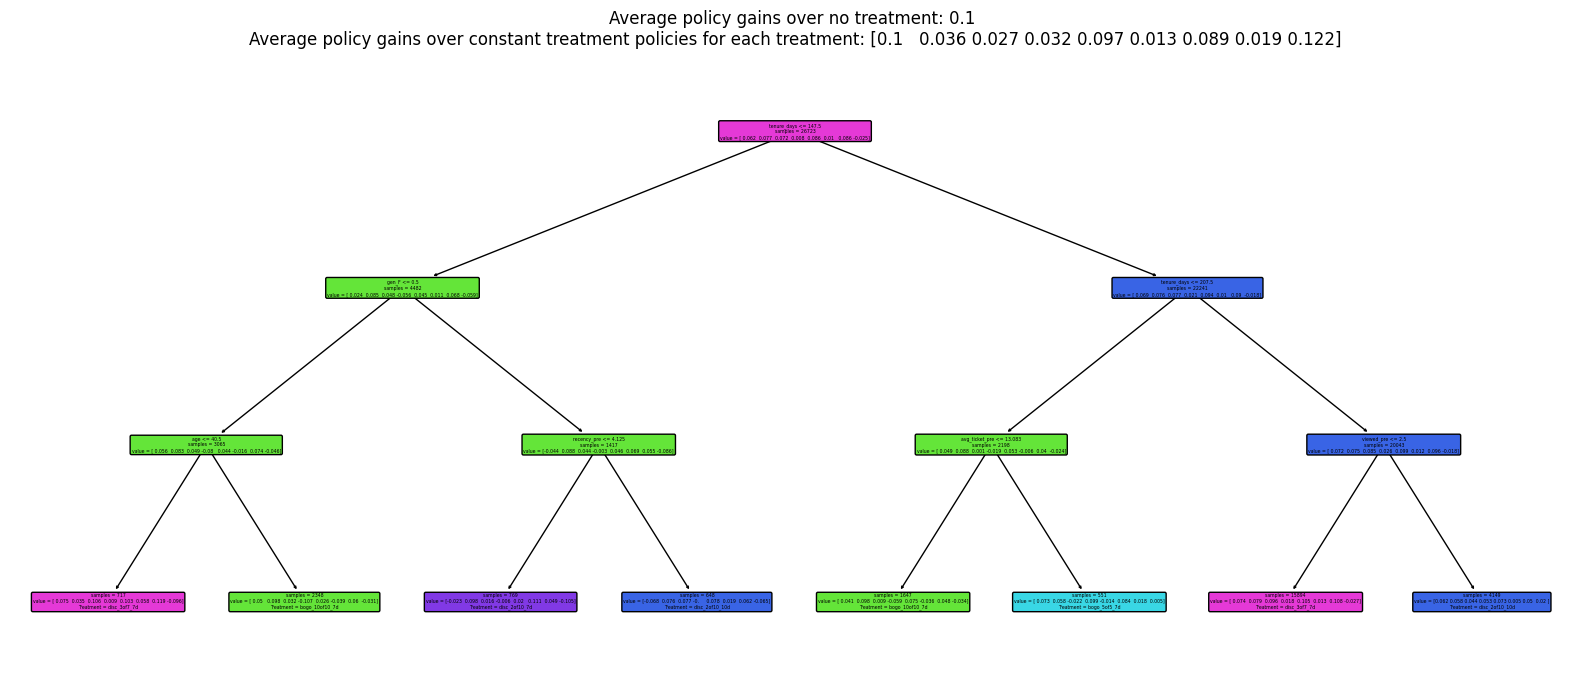

In [0]:
try:
    from econml.policy import DRPolicyTree
    ptree = DRPolicyTree(model_regression=lgb_r(), model_propensity=lgb_c(),
                         max_depth=3, min_samples_leaf=500, cv=3, random_state=SEED)
    ptree.fit(Y_tr, T_tr, X=X_tr)
    fig, ax = plt.subplots(figsize=(16, 7))
    ptree.plot(ax=ax, feature_names=X_COLS, treatment_names=labels)
    plt.tight_layout(); plt.show()
except Exception as e:
    # Fallback across econml API versions: policy interpreter over the fitted forest
    print("DRPolicyTree unavailable ->", e, "\nFalling back to SingleTreePolicyInterpreter.")
    from econml.cate_interpreter import SingleTreePolicyInterpreter
    costs = np.tile(cost[labels[1:]].values / ticket, (len(X_te), 1))   # cost in probability units
    interp = SingleTreePolicyInterpreter(max_depth=3, min_samples_leaf=500, risk_level=None)
    interp.interpret(cf_y1, X_te, sample_treatment_costs=costs)
    fig, ax = plt.subplots(figsize=(16, 7))
    interp.plot(ax=ax, feature_names=X_COLS, treatment_names=labels)
    plt.tight_layout(); plt.show()

## 10. Refutation tests

**Placebo:** permute treatment within each send wave (preserves the experiment's structure,
destroys the T→Y link). Estimated with the same clustered OLS as Section 2 — all effects must be
statistically indistinguishable from zero. With 8 arms at 95%, one marginal escape is expected
noise (~34% family-wise); several arms out, or magnitudes near the real effects, would flag a
pipeline problem.

In [0]:
rng = np.random.default_rng(SEED)
tr_pl = tr.copy()
tr_pl["T_placebo"] = tr_pl.groupby("t0")["T"].transform(lambda s: rng.permutation(s.values))
inv = {v: k for k, v in code_map.items()}
tr_pl["t_label_pl"] = tr_pl["T_placebo"].map(inv)

ols_pl = smf.ols("y1_conv_7d ~ C(t_label_pl, Treatment('control'))", data=tr_pl).fit(
    cov_type="cluster", cov_kwds={"groups": tr_pl["account_id"]})
placebo = extract_ols(ols_pl, "C(t_label_pl, Treatment('control'))") \
            .rename(columns={"ATE_ols": "ATE_placebo"})
placebo["CI_covers_zero"] = (placebo["CI_low"] <= 0) & (0 <= placebo["CI_high"])
placebo.round(4)

,offer,ATE_placebo,CI_low,CI_high,CI_covers_zero
0,bogo_10of10_5d,0.0108,-0.0021,0.0237,True
1,bogo_10of10_7d,0.0027,-0.0104,0.0157,True
2,bogo_5of5_5d,-0.0013,-0.0144,0.0118,True
3,bogo_5of5_7d,0.0069,-0.0059,0.0197,True
4,disc_2of10_10d,-0.0020,-0.0151,0.0110,True
5,disc_2of10_7d,0.0007,-0.0122,0.0137,True
6,disc_3of7_7d,0.0013,-0.0115,0.0141,True
7,disc_5of20_10d,0.0046,-0.0083,0.0175,True


**Window-overlap sensitivity:** naive uplifts on the overlap-free subset (~18% of the base) must point in the same direction as the full-sample estimates. Expect larger magnitudes (cleaner windows, fewer offers received) and noise on the near-zero arms (~1.4k obs/arm).

In [0]:
clean = tr[tr["n_overlapping_offers"] == 0]
sens = diff_in_means(tr).merge(
    diff_in_means(clean).rename(columns={"ATE_naive": "ATE_no_overlap"})[["offer", "ATE_no_overlap"]],
    on="offer")
sens[["offer", "ATE_naive", "ATE_no_overlap"]].round(4)

,offer,ATE_naive,ATE_no_overlap
0,bogo_10of10_5d,0.0652,0.0921
1,bogo_10of10_7d,0.0685,0.0858
2,bogo_5of5_5d,0.0609,0.0873
3,bogo_5of5_7d,0.0040,-0.0233
4,disc_2of10_10d,0.0822,0.1216
5,disc_2of10_7d,0.0032,-0.0007
6,disc_3of7_7d,0.0772,0.1196
7,disc_5of20_10d,-0.0194,-0.0454


## 11. Results, conclusions and assumptions

### Headline results (executed run)

| Finding | Evidence |
|---|---|
| Most conversions would happen without a coupon | 77.5% 7-day conversion in the control group; 25.8% of completions occur without a prior view |
| Average effects are small and highly heterogeneous | ATEs from −1.9 to +8.4 p.p. (clustered OLS, 95% CIs); DML points inside the OLS CI for all 8 arms; individual CATEs from −10 to +24 p.p. |
| Delivery decides | The two offers without the social channel have effects ≈ 0 (view rate 54% vs. 96%); same discount, ~8 p.p. difference |
| One offer destroys value | R$5 discount / R$20 minimum / weak channels: −1.9 p.p. (95% CI [−3.1, −0.7]) while still paying rewards |
| Discounts pull purchases forward — they do not build habit | Post-expiry retention ATEs ≤ 0 in **all 8 arms** (two significantly negative: disc_2of10_7d −2.1 p.p., disc_5of20_10d −2.2 p.p.); the lightest offer (bogo_5of5_5d) is the only one near zero, with 53% of customers showing a positive individual effect |
| Offers change purchase *timing*, not purchase *size* | Mean ticket inside vs. outside active offer windows: R$ 12.78 vs. R$ 12.74 (NB1 §7.5) |
| Coupons activate dormant customers | Most sensitive quartile: 1.6 prior purchases on average vs. 3.6 in the least sensitive; heterogeneity driven by tenure, recency and prior spend |
| Targeting beats mass sending | Policy: **+R$ 17.3k / 10k customers** vs. +R$ 14.8k (best single offer) vs. **−R$ 12.4k (random allocation)** — a ~R$ 29.7k swing; 16.4% of the base receives no discount; 71% concentrated on the champion offer (R$2 / min R$10 / 10d) |
| Policy value survives doubly-robust scrutiny | 884 (plug-in) vs. 864 (DR) incremental conversions per 10k customers — a 2.3% gap; the model component is doing the work, the propensity correction barely moves it |
| Placebo clean | All 8 permuted-treatment effects statistically zero (clustered OLS) |
| Model calibrated where it matters | Champion-offer decile calibration monotonic along the 45° line; Qini well above random |

### Model comparison (Section 6) — reading

| Model | R-score | AUUC (champion arm) |
|---|---|---|
| **SLearner** | **0.0061** | **52.6** |
| CausalForestDML | 0.0039 | 44.5 |
| XLearner | −0.0235 | 42.1 |
| TLearner | −0.0405 | 38.8 |
| LinearDML | 0.0014 | 23.4 |
| DRLearner | −0.1110 | 19.7 |

Three takeaways:
1. **The S-learner edges the causal forest on both criteria.** Plausible in this setting: treatment
   is randomized and low-dimensional (9 arms, 15 features, 53k training rows), so a single pooled
   LightGBM with the arm as a feature borrows strength across arms efficiently; its known
   attenuation bias is inconsequential for *ranking*, which is what AUUC (and the policy) consume.
2. **Heterogeneity is genuinely non-linear.** LinearDML posts a positive R-score but the weakest
   useful AUUC — linear-in-X effects cannot express the dormancy × tenure interactions the tree
   models exploit.
3. **DRLearner suffers from pseudo-outcome variance:** with arm propensities ≈ 0.1, its
   doubly-robust pseudo-outcomes carry ~10× weights, and the final regressor partly fits that
   noise.

**Decision:** the CausalForestDML remains the primary CATE engine (native multi-valued treatment,
honest splitting, X/W separation, uncertainty machinery); the S-learner is documented as an equally
valid — and operationally cheaper — alternative whose CATEs can be swapped into the policy layer
with one line. The policy conclusion is learner-robust; the ranking of offers and the shape of the
allocation do not depend on this choice.

### Modeling assumptions

1. **Inference:** average effects via saturated OLS with customer-clustered SEs (exact under
   randomization). The forest provides CATE points and the policy; per-individual CATE intervals
   are not reported (the forest's bootstrap does not cluster by customer).
2. **Monetization:** mean conversion ticket (R$ 33.57) held constant across segments; offer cost =
   mean observed reward per send (embeds completion probability; overstates cost for low-propensity
   customers). Natural refinement: model 7-day spend as a second continuous outcome.
3. **Channels are part of the offer package:** estimated effects are for offers *as delivered*.
   Separating price elasticity from channel effects would require experimental channel variation
   within the same offer.
4. **Off-policy evaluation** on the randomized holdout (plug-in + doubly robust, 2.3% apart);
   definitive validation is the production A/B test proposed in the presentation.
5. **Feature-rank note:** `incomplete_profile` is perfectly collinear with the omitted gender dummy
   (profile missingness is structural — age/gender/limit fail together), so it is dropped from the
   LinearDML final stage only; tree-based methods keep the full set.
6. All data-construction assumptions inherited from Notebook 1, Section 11.
